# Decision Trees

# Regression

We've considered trees within the context of classification. Trees can also be made to work in the case of regression (that is, continuous rather than categorical variables). The estimator to use for this is the ```DecisionTreeRegressor``` or ```RandomForestRegressor```, and the syntax is very similar to what we saw earlier.

Consider the following data, drawn from the combination of a fast and slow oscillation:

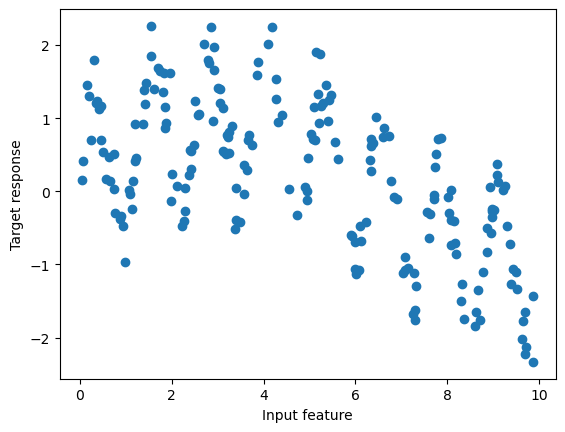

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

t = model(x)
plt.scatter(x, t);
plt.xlabel('Input feature')
plt.ylabel('Target response');

Using the random forest regressor, we can find the best fit curve as follows:

In [2]:
from sklearn.tree import DecisionTreeRegressor

DecisionTreeRegressor?

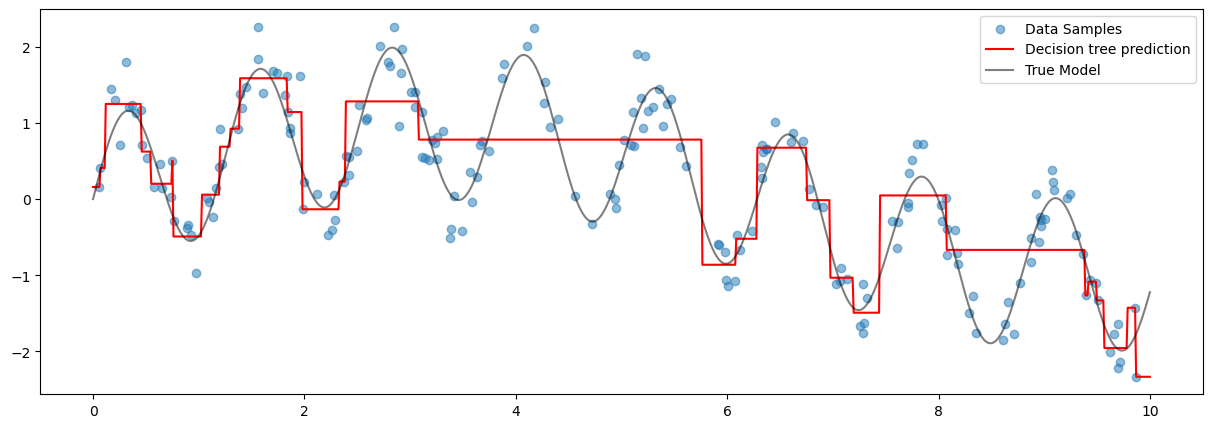

In [3]:
dt_reg = DecisionTreeRegressor(max_depth=5)
dt_reg.fit(x[:, np.newaxis], t)

xfit = np.linspace(0, 10, 1000)
yfit = dt_reg.predict(xfit[:, np.newaxis])
ytrue = model(xfit, sigma=0)

plt.figure(figsize=(15,5))
plt.scatter(x, t, alpha=0.5, label='Data Samples')
plt.plot(xfit, yfit, '-r', label='Decision tree prediction');
plt.plot(xfit, ytrue, '-k', alpha=0.5, label='True Model');
plt.legend();

Here the true model is shown in the smooth gray curve, while the random forest model is shown by the jagged red curve. As you can see, the non-parametric random forest model is flexible enough to fit the multi-period data, without us needing to specifying a multi-period model!

The CART algorithm works mostly the same way as earlier, except that instead of trying to split the training set in a way that minimizes impurity, it now tries to split the training set in a way that **minimizes the MSE**.

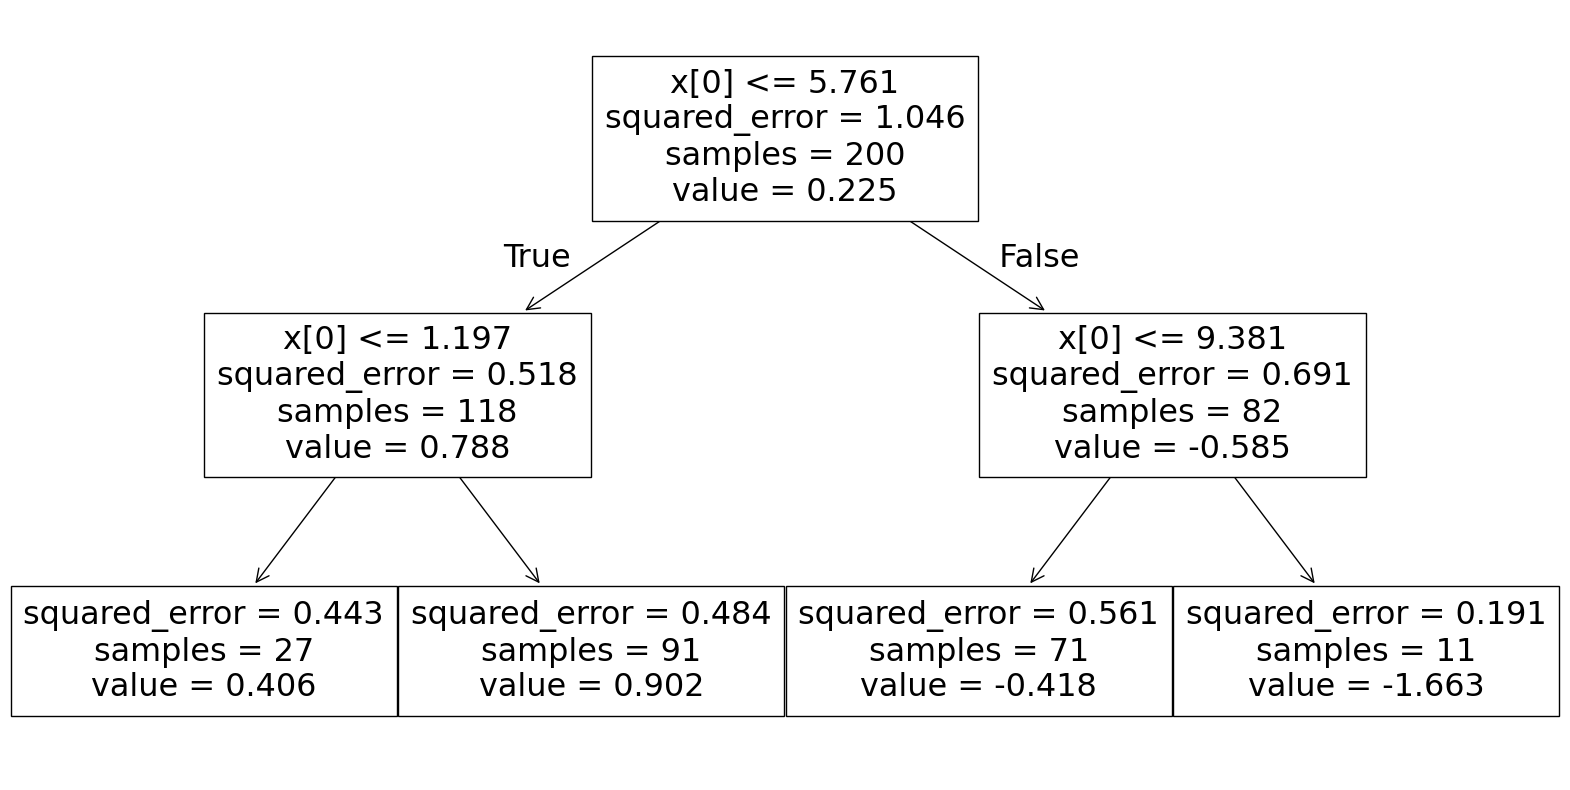

In [4]:
from sklearn.tree import plot_tree


dt_reg = DecisionTreeRegressor(max_depth=2)
dt_reg.fit(x[:, np.newaxis], t)

plt.figure(figsize=(20,10))
plot_tree(dt_reg);

---

# Ensembles of Estimators: Random Forests

This notion - that multiple overfitting estimators can be combined to reduce the effect of this overfitting - is what underlies an ensemble method called **bagging**. 

**Bagging**, which stands for **bootstrap aggregating**, makes use of an ensemble (a grab bag, perhaps) of parallel estimators, each of which overfits the data, and averages the results to find a better classification. An ensemble of randomized decision trees is known as a **random forest**.

* Note: a *bootstrap sample* is a sample taken from the original data set with replacement. The bootstrap sample is the same size as the original.

This type of bagging classification can be done manually using Scikit-Learn's ```BaggingClassifier``` meta-estimator, as shown here:

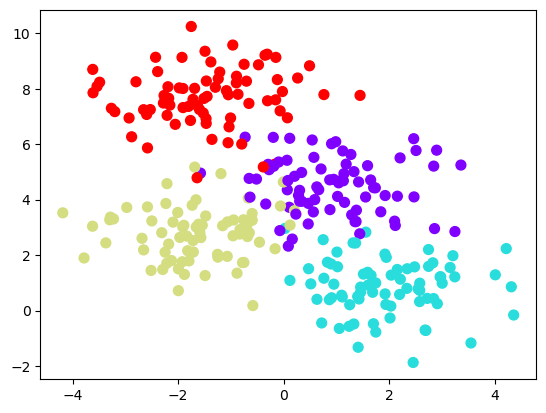

In [5]:
from sklearn.datasets import make_blobs

X, t = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='rainbow');

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    stratify=t,
                                                   test_size=0.2)

In [7]:
from ipywidgets import interact

def visualize_classifier(model, X, t, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=t, s=30, cmap=cmap,
               clim=(t.min(), t.max()), zorder=3)
    ax.axis('tight')
#     ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, t)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(t))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

BaggingClassifier?



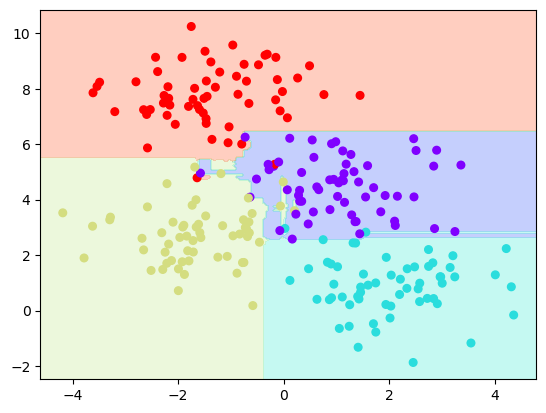

In [9]:
tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=500,
                       bootstrap=True,
                       oob_score=True,
                       max_samples=0.8,
                       random_state=1)

bag.fit(X, t)
visualize_classifier(bag, X_train, t_train)

In this example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points. In practice, decision trees are more effectively randomized by injecting some stochasticity in how the splits are chosen: this way all the data contributes to the fit each time, but the results of the fit still have the desired randomness. For example, when determining which feature to split on, the randomized tree might select from among the top several features. You can read more technical details about these randomization strategies in the [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/ensemble.html#forest) and references within.

---

## Out-of-Bag Evaluation

With bagging, some instances may be sampled several times for any given predictor, while others may not be sampled at all. By default a ```BaggingClassifier``` samples $m$ training instances with replacement (```bootstrap=True```), where $m$ is the size of the training set. This means that only about 63% of the training instances are sampled on average for each predictor. The remaining 37% of the training instances that are not sampled are called **out-of-bag (oob) instances**. Note that they are not the same 37% for all predictors. 

A bagging ensemble can be evaluated using oob instances, without the need for a separate validation set: indeed, if there are enough estimators, then each instance in the training set will likely be an oob instance of several estimators, so these estimators can be used to make a fair ensemble prediction for that instance. Once you have a prediction for each instance, you can compute the ensemble's prediction accuracy (or any other metric).

In [10]:
bag.oob_score_

0.9125

In [11]:
y_test = bag.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

accuracy_score(t_test, y_test)

0.9333333333333333

In [13]:
bag.oob_decision_function_

# access probabilities for the oob samples

array([[1.        , 0.        , 0.        , 0.        ],
       [0.67410714, 0.        , 0.05803571, 0.26785714],
       [0.        , 0.        , 0.99547511, 0.00452489],
       [0.        , 1.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 0.00444444, 0.99555556, 0.        ],
       [0.99190283, 0.        , 0.00404858, 0.00404858],
       [0.84140969, 0.        , 0.        , 0.15859031],
       [0.        , 0.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.62882096, 0.01746725, 0.06113537, 0.29257642],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        , 0.        ],
       [0.01321586, 0.        , 0.        , 0.98678414],
       [0.00930233, 0.        , 0.        , 0.99069767],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.        ,

In Scikit-Learn, such an optimized ensemble of randomized decision trees is implemented in the ```RandomForestClassifier``` estimator, which takes care of all the randomization automatically. All you need to do is select a number of estimators, and it will very quickly (in parallel, if desired) fit the ensemble of trees:`

In [14]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier?

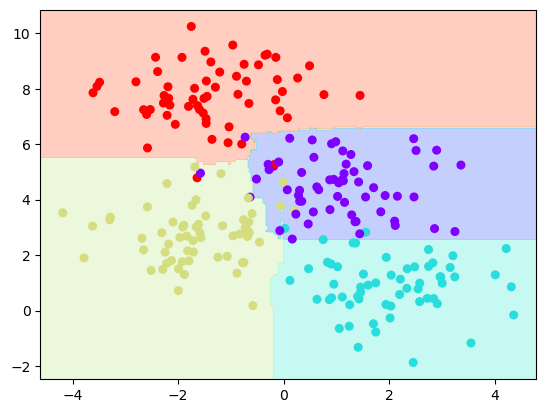

In [15]:
model = RandomForestClassifier(n_estimators=100,
                               max_depth=4,
                              random_state=0)

visualize_classifier(model, X_train, t_train);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

In [16]:
model.feature_importances_ #The relative importance of each feature to make a decision about a class

array([0.36305336, 0.63694664])

---

## Hyperparameters

With a few exceptions, a ```RandomForestClassifier``` has all the hyperparameters of a ```DecisionTreeClassifier``` (to control how trees are grown), plus all the hyperparameters of a ```BaggingClassifier``` to control the ensemble itself.

The Random Forest algorithm introduces extra randomness when growing trees; instead of searching for the very best feature when splitting a node, it **searches for the best feature among a random subset of features**. The algorithm results in greater tree diversity, which (again) trades a higher bias for a lower variance generally yielding an overall better model. The following is equivalent to the previous ```RandomForestClassifier```:

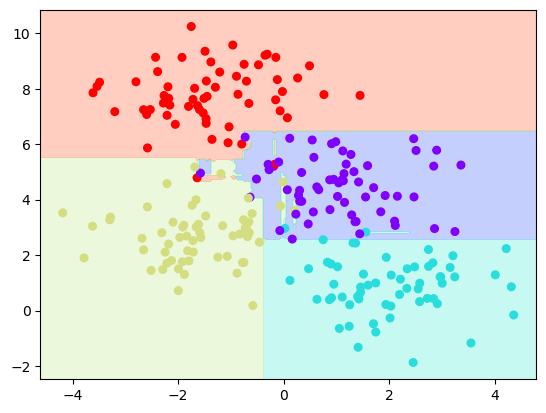

In [17]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(),
                           n_estimators=100,
                           bootstrap=True,
                           random_state=0)

visualize_classifier(bag_clf, X_train, t_train);

---

## Summary of Random Forests

Random forest is a type of *ensemble estimators*. Random forests are a powerful method with several **advantages**:

* Both training and prediction are very fast, because of the simplicity of the underlying decision trees. In addition, both tasks can be straightforwardly parallelized, because the individual trees are entirely independent entities.

* The multiple trees allow for a probabilistic classification: a majority vote among estimators gives an estimate of the probability (accessed in Scikit-Learn with the ```predict_proba()``` method).

* The non-parametric model is extremely flexible, and can thus perform well on tasks that are underfit by other estimators.

A primary **disadvantage** of random forests is that the results are not easily interpretable: that is, if you would like to draw conclusions about the meaning of the classification model, random forests may not be the best choice.

---

# Comparing Logistic Regression, Decision Trees & Random Forests for Classification Tasks

In [18]:
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix

C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\aramirezsalgado\AppData\Local\anaconda3\envs\ramirez_env\lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will 

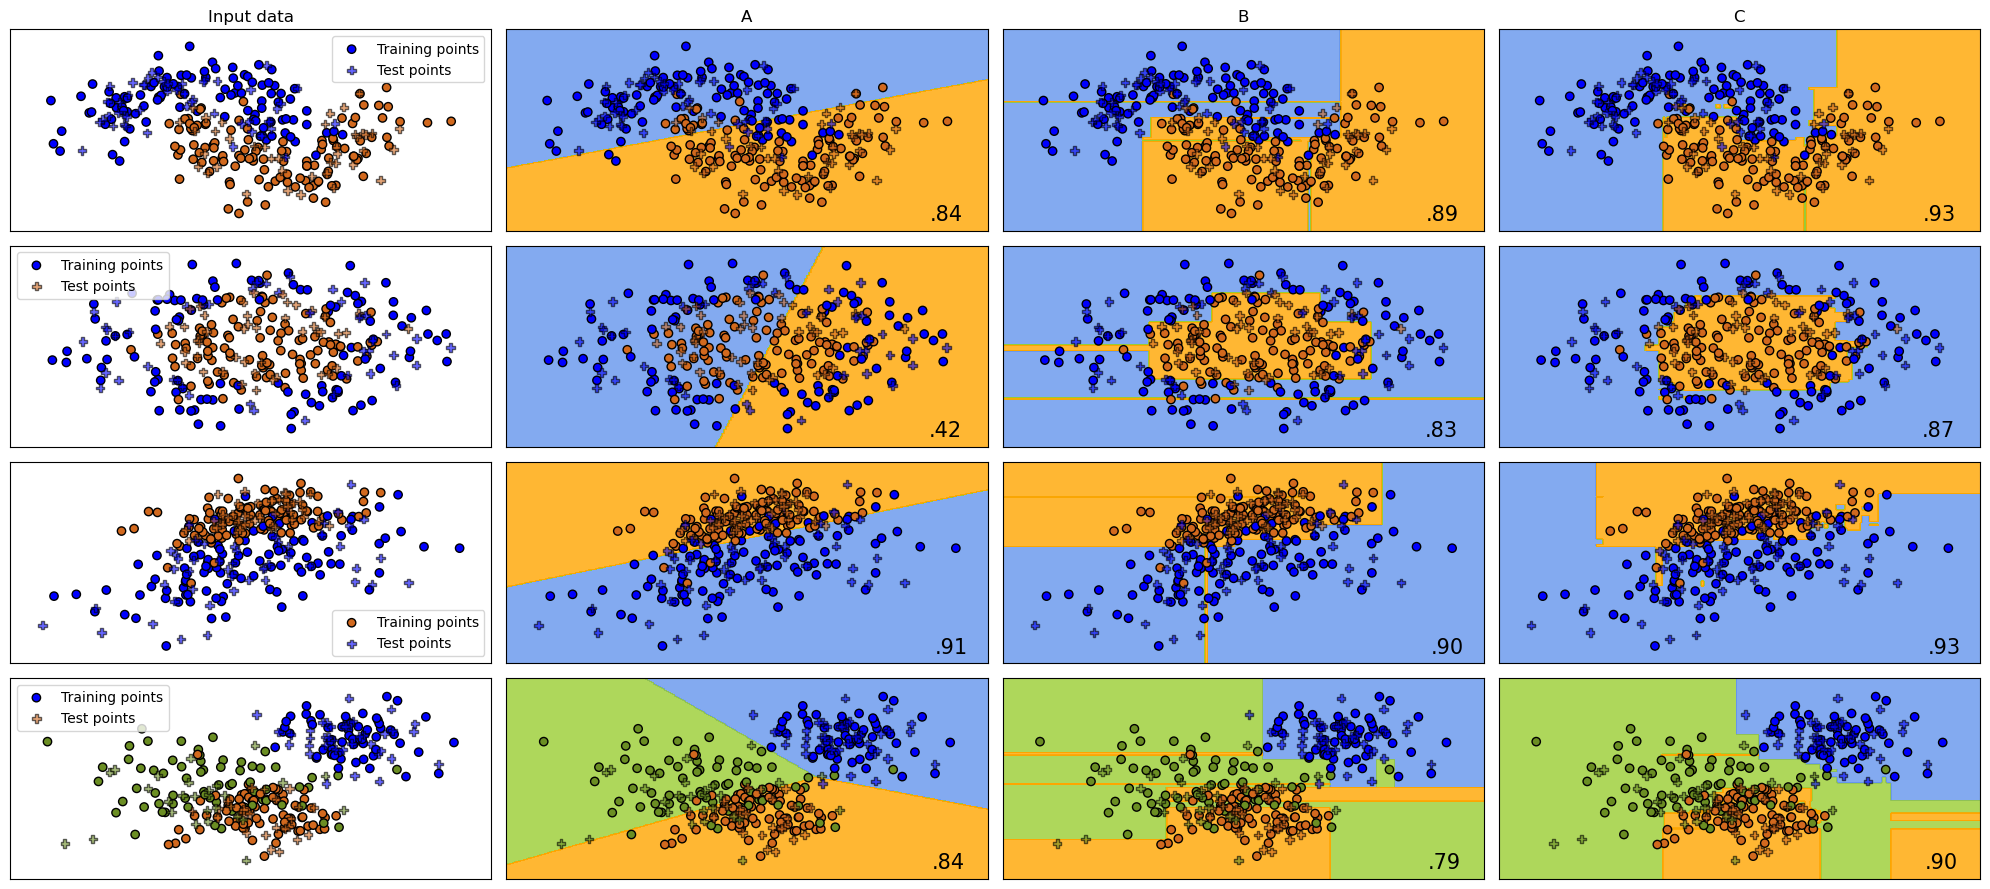

In [19]:
# Source: https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py

# figure parameters
h = .02  # step size in the mesh
figure = plt.figure(figsize=(20, 9))

# set up classifiers
n_neighbors = 5
classifiers = [LogisticRegression(multi_class='multinomial',solver='lbfgs'),\
               DecisionTreeClassifier(max_depth=5),\
               RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
              ]
# names = ['Logistic Regression','Decision Tree', 'Random Forest']

names = ['A','B','C']

# Put together Data Sets
n_samples = 300
X, y = make_classification(n_samples=n_samples, n_features=2, n_redundant=0, n_informative=2,
                           random_state=0, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 1*rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [make_moons(noise=0.3, random_state=0,n_samples=n_samples),
            make_circles(noise=0.2, factor=0.5, random_state=1,n_samples=n_samples),
            linearly_separable,
            make_blobs(random_state=1,cluster_std=[3.0,4.0,2.5],n_samples=n_samples)
            ]

i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=.3, random_state=42)

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # just plot the dataset first
    cm = ListedColormap(['cornflowerblue','yellowgreen','orange']) #plt.cm.RdBu
    cm_bright = ListedColormap(['blue','olivedrab','chocolate'])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
               edgecolors='k',label='Training points')
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=y_test, cmap=cm_bright, alpha=0.6,
               edgecolors='k',label='Test points')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())
    ax.set_yticks(())
    ax.legend()
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)

        # Plot the decision boundary. For that, we will assign a color to each
        # point in the mesh [x_min, x_max]x[y_min, y_max].
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
#         Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
                   edgecolors='k')
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], marker='P', c=y_test, cmap=cm_bright,
                   edgecolors='k', alpha=0.6)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                size=15, horizontalalignment='right')
        i += 1

plt.tight_layout()
plt.show()

---

---